In [1]:
import numpy as np
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import multimin as mm
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from utils.Utils import (
    CanonicalUnits, 
    GravitationalParameters,
    trasformation_X_to_E,
    compute_jacobian_XoE,
    Jacobian_qei_to_QEI,
    P_E_CMND
    )

In [2]:
deg = np.pi/180
AU_m = 1.496e11 #m
M_sun = 1.9891e30
G = 6.67430e-11 # m^3 / (kg s^2)
year = 365.25*24*3600 #s
mu = CanonicalUnits().mu
grav_params = GravitationalParameters(mu=mu)

c:\Users\aguju\Documents\tesis\juanita\juanita\repo\TesisRepo\density_space_mapping\multimin.py:255: UserWarning: The figure layout has changed to tight
  self.fig.tight_layout()


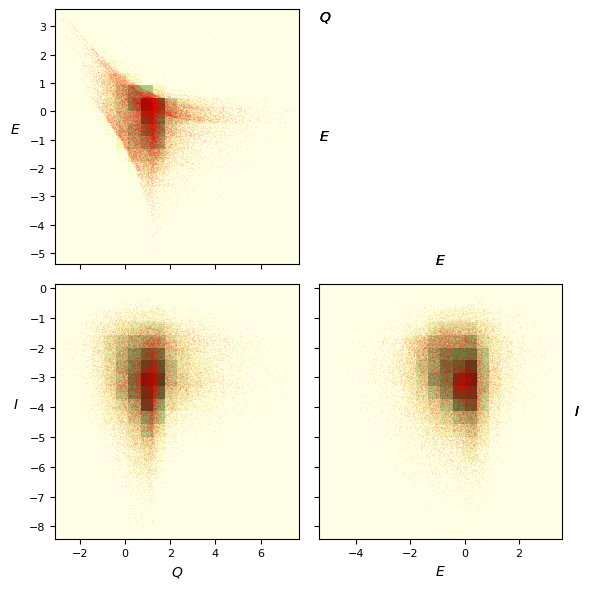

In [3]:
F = mm.FitCMND(f"../multimin/products/fit-NEAs-qei-Ng10-Nv3-rad.pkl")

props=["Q","E","I"]
hargs=dict(bins=20,cmap='YlGn')
sargs=dict(s=0.2,edgecolor='None',color='r', alpha=0.3)
G=F.plotFit(props=props,hargs=hargs,sargs=sargs,figsize=3)

In [4]:
def P_X_CMND(x: np.array, y: np.array, z: np.array, vx: np.array, vy: np.array, vz: np.array, q_max: float, e_max: float, i_max: float, mu: float, F: mm.FitCMND) -> np.array:
    """
    Vectorized version: x, y, vx, vy are arrays (or scalars).
    Returns array of P values.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    z = np.asarray(z)
    vx = np.asarray(vx)
    vy = np.asarray(vy)
    vz = np.asarray(vz)
    # Prepare output array
    shape = np.broadcast(x, y, z, vx, vy, vz).shape
    P = np.empty(shape, dtype=float)

    # Flatten for iteration if needed
    x_flat = x.ravel()
    y_flat = y.ravel()
    z_flat = z.ravel()
    vx_flat = vx.ravel()
    vy_flat = vy.ravel()
    vz_flat = vz.ravel()

    for idx in range(x_flat.size):
        q, e, i, Omega, w, M, a = trasformation_X_to_E(x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx], mu)
        #print("evaluating at: ", x_flat[idx], y_flat[idx], z_flat[idx], vx_flat[idx], vy_flat[idx], vz_flat[idx])
        #print("orbital elements: ", q, e, i, Omega, w, M, a)
        if q > 1.35 or e >= 1:
            #print(" ----------------- Not sense orbit -----------------")
            P.flat[idx] = 0
        else:
            with np.errstate(divide='ignore', invalid='ignore'):
                J = compute_jacobian_XoE(a,e,i,Omega,w,M,mu)
                J_qei_to_QEI = Jacobian_qei_to_QEI(q,e,i,q_max,e_max,i_max)
                det = np.linalg.det(J)
                det_QEI = np.linalg.det(J_qei_to_QEI)
                if det == 0 or not np.isfinite(det):
                    #print(" ----------------- Cero determinant -----------------")
                    P.flat[idx] = np.nan
                else:
                    inv_det = 1.0/det 
                    P.flat[idx] = P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)
                    #if np.isnan(P_E_CMND(q, e, i, F) * abs(inv_det) * abs(det_QEI)):
                    #    print("Nan value encounter: ", P_E_CMND(q, e, i, F), abs(inv_det), abs(det_QEI))
                    #print(P_E_CMND(a, e, i, F) * abs(inv_det) * abs(det_AEI)) 
    
    return P.reshape(shape)

In [ ]:
def v_box_surface_integral_P_X_CMND(center, widths, velocities, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the integral of P_X_CMND over a position box (x, y, z) with fixed velocities.
    Integrates only over positions in a box centered at (cx, cy, cz) with widths (dx, dy, dz),
    while keeping velocities constant (vx = cte, vy = cte, vz = cte).

    Parameters:
        center: tuple/list/array of (cx, cy, cz) position center
        widths: tuple/list/array of (dx, dy, dz) position side lengths
        velocities: tuple/list/array of (vx, vy, vz) constant velocities
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension
        mu: gravitational parameter
        F: FitCMND object

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    cvx, cvy, cvz = center
    dvx, dvy, dvz = widths
    x, y, z = velocities
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for position dimensions only
    vx_pts = cvx + 0.5*dvx*pts
    vy_pts = cvy + 0.5*dvy*pts
    vz_pts = cvz + 0.5*dvz*pts

    # Create meshgrid only for position quadrature points
    VX, VY, VZ = np.meshgrid(vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ = np.meshgrid(wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ).ravel()
    
    # Create constant velocity arrays (same size as position arrays)
    Xf = np.full_like(VXf, x)
    Yf = np.full_like(VYf, y)
    Zf = np.full_like(VZf, z)
    
    # Evaluate P at all points with constant velocities
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor (only position dimensions)
    integral = np.sum(Pf * WF) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    return integral

In [13]:
def r_box_surface_integral_P_X_CMND(center, widths, position, max_elements: list, n_points=8, mu=1, F=mm.FitCMND):
    """
    Calculate the integral of P_X_CMND over a position box (x, y, z) with fixed velocities.
    Integrates only over positions in a box centered at (cx, cy, cz) with widths (dx, dy, dz),
    while keeping velocities constant (vx = cte, vy = cte, vz = cte).

    Parameters:
        center: tuple/list/array of (cx, cy, cz) position center
        widths: tuple/list/array of (dx, dy, dz) position side lengths
        velocities: tuple/list/array of (vx, vy, vz) constant velocities
        max_elements: tuple/list/array of (q_max, e_max, i_max) max elements
        n_points: number of quadrature points per dimension
        mu: gravitational parameter
        F: FitCMND object

    Returns:
        Integral (float)
    """
    from numpy.polynomial.legendre import leggauss

    cvx, cvy, cvz = center
    dvx, dvy, dvz = widths
    x, y, z = position
    q_max, e_max, i_max = max_elements

    # Get Gauss-Legendre points and weights for [-1, 1]
    pts, wts = leggauss(n_points)

    # Map points from [-1, 1] to [center-width/2, center+width/2] for position dimensions only
    vx_pts = cvx + 0.5*dvx*pts
    vy_pts = cvy + 0.5*dvy*pts
    vz_pts = cvz + 0.5*dvz*pts

    # Create meshgrid only for position quadrature points
    VX, VY, VZ = np.meshgrid(vx_pts, vy_pts, vz_pts, indexing='ij')
    WX, WY, WZ = np.meshgrid(wts, wts, wts, indexing='ij')

    # Flatten for vectorized evaluation
    VXf = VX.ravel()
    VYf = VY.ravel()
    VZf = VZ.ravel()
    WF = (WX * WY * WZ).ravel()
    
    # Create constant velocity arrays (same size as position arrays)
    Xf = np.full_like(VXf, x)
    Yf = np.full_like(VYf, y)
    Zf = np.full_like(VZf, z)
    
    # Evaluate P at all points with constant velocities
    Pf = P_X_CMND(Xf, Yf, Zf, VXf, VYf, VZf, q_max, e_max, i_max, mu, F=F)

    # Integral is sum(P * weight) * volume factor (only position dimensions)
    integral = np.sum(Pf * WF) * (0.5*dvx) * (0.5*dvy) * (0.5*dvz)
    return integral

In [17]:
vx_min, vx_max = -10, 10
vy_min, vy_max = -10, 10

vz_center = 0.0

dvx_cell, dvy_cell, dvz_cell = 0.1, 0.1, 0.1
widths = np.array([dvx_cell, dvy_cell, dvz_cell])

x = -1.0
y = 0.0
z = 0.0
center_r = np.array([x, y, z])

max_elements = (1.35, 1.0, np.pi) 

vx_vals = np.arange(vx_min, vx_max + dvx_cell, dvx_cell)
vy_vals = np.arange(vy_min, vy_max + dvy_cell, dvy_cell)

degree = 6

dtype = [
    ("value", float),
    ("x", float),
    ("y", float)
]

probability_map = np.zeros((len(vy_vals), len(vx_vals)), dtype=dtype)

print("Starting probability mapping...")
for i, vy_c in enumerate(tqdm(vy_vals, desc="Y-axis progress")):
    for j, vx_c in enumerate(vx_vals):         

        center = np.array([vx_c, vy_c, vz_center])

        try:
        # Calculate the integral for this hypervolume
            prob_value = r_box_surface_integral_P_X_CMND(
                center, widths, 
                center_r, 
                max_elements, 
                degree, 
                mu=mu, 
                F=F
            )
        except Exception as err:
            print("Runtime error at center =", center)
            print("   → Setting integral to NaN.")
            #print("   Error message:", err)
            prob_value = np.nan

        # Store the result
        # Note: In plotting, the first index (i) corresponds to rows (y-axis)
        probability_map[i, j] = (prob_value, vx_c, vy_c)
        print(vx_c, vy_c, prob_value, i, j)
     
# Save to a .dat file
print("Mapping complete!")
np.save(f"data_results/method 6/PX_fixedv_vxmin={vx_min}_vxmax={vx_max}_vymin={vy_min}_vymax={vy_max}_x={x}.npy", probability_map)

Starting probability mapping...


Y-axis progress:   0%|          | 0/201 [00:00<?, ?it/s]

-10.0 -10.0 0.0 0 0
-9.9 -10.0 0.0 0 1
-9.8 -10.0 0.0 0 2
-9.700000000000001 -10.0 0.0 0 3
-9.600000000000001 -10.0 0.0 0 4
-9.500000000000002 -10.0 0.0 0 5
-9.400000000000002 -10.0 0.0 0 6
-9.300000000000002 -10.0 0.0 0 7
-9.200000000000003 -10.0 0.0 0 8
-9.100000000000003 -10.0 0.0 0 9
-9.000000000000004 -10.0 0.0 0 10
-8.900000000000004 -10.0 0.0 0 11
-8.800000000000004 -10.0 0.0 0 12
-8.700000000000005 -10.0 0.0 0 13
-8.600000000000005 -10.0 0.0 0 14
-8.500000000000005 -10.0 0.0 0 15
-8.400000000000006 -10.0 0.0 0 16
-8.300000000000006 -10.0 0.0 0 17
-8.200000000000006 -10.0 0.0 0 18
-8.100000000000007 -10.0 0.0 0 19
-8.000000000000007 -10.0 0.0 0 20
-7.9000000000000075 -10.0 0.0 0 21
-7.800000000000008 -10.0 0.0 0 22
-7.700000000000008 -10.0 0.0 0 23
-7.6000000000000085 -10.0 0.0 0 24
-7.500000000000009 -10.0 0.0 0 25
-7.400000000000009 -10.0 0.0 0 26
-7.30000000000001 -10.0 0.0 0 27
-7.20000000000001 -10.0 0.0 0 28
-7.10000000000001 -10.0 0.0 0 29
-7.000000000000011 -10.0 0.0 0 3

Y-axis progress:   0%|          | 1/201 [00:00<01:13,  2.72it/s]

 -10.0 0.0 0 101
0.19999999999996376 -10.0 0.0 0 102
0.2999999999999634 -10.0 0.0 0 103
0.39999999999996305 -10.0 0.0 0 104
0.4999999999999627 -10.0 0.0 0 105
0.5999999999999623 -10.0 0.0 0 106
0.699999999999962 -10.0 0.0 0 107
0.7999999999999616 -10.0 0.0 0 108
0.8999999999999613 -10.0 0.0 0 109
0.9999999999999609 -10.0 0.0 0 110
1.0999999999999606 -10.0 0.0 0 111
1.1999999999999602 -10.0 0.0 0 112
1.2999999999999599 -10.0 0.0 0 113
1.3999999999999595 -10.0 0.0 0 114
1.4999999999999591 -10.0 0.0 0 115
1.5999999999999588 -10.0 0.0 0 116
1.6999999999999584 -10.0 0.0 0 117
1.799999999999958 -10.0 0.0 0 118
1.8999999999999577 -10.0 0.0 0 119
1.9999999999999574 -10.0 0.0 0 120
2.099999999999957 -10.0 0.0 0 121
2.1999999999999567 -10.0 0.0 0 122
2.2999999999999563 -10.0 0.0 0 123
2.399999999999956 -10.0 0.0 0 124
2.4999999999999556 -10.0 0.0 0 125
2.5999999999999552 -10.0 0.0 0 126
2.699999999999955 -10.0 0.0 0 127
2.7999999999999545 -10.0 0.0 0 128
2.899999999999954 -10.0 0.0 0 129
2.99999

...

9.499999999999929 9.79999999999993 0.0 198 195
9.59999999999993 9.79999999999993 0.0 198 196
9.699999999999932 9.79999999999993 0.0 198 197
9.79999999999993 9.79999999999993 0.0 198 198
9.899999999999928 9.79999999999993 0.0 198 199
9.999999999999929 9.79999999999993 0.0 198 200
-10.0 9.899999999999928 0.0 199 0
-9.9 9.899999999999928 0.0 199 1
-9.8 9.899999999999928 0.0 199 2
-9.700000000000001 9.899999999999928 0.0 199 3
-9.600000000000001 9.899999999999928 0.0 199 4
-9.500000000000002 9.899999999999928 0.0 199 5
-9.400000000000002 9.899999999999928 0.0 199 6
-9.300000000000002 9.899999999999928 0.0 199 7
-9.200000000000003 9.899999999999928 0.0 199 8
-9.100000000000003 9.899999999999928 0.0 199 9
-9.000000000000004 9.899999999999928 0.0 199 10
-8.900000000000004 9.899999999999928 0.0 199 11
-8.800000000000004 9.899999999999928 0.0 199 12
-8.700000000000005 9.899999999999928 0.0 199 13
-8.600000000000005 9.899999999999928 0.0 199 14
-8.500000000000005 9.899999999999928 0.0 199 15
-8.

Y-axis progress: 100%|█████████▉| 200/201 [2:26:31<00:00,  1.39it/s]

2.899999999999954 9.899999999999928 0.0 199 129
2.999999999999954 9.899999999999928 0.0 199 130
3.0999999999999535 9.899999999999928 0.0 199 131
3.199999999999953 9.899999999999928 0.0 199 132
3.2999999999999527 9.899999999999928 0.0 199 133
3.3999999999999524 9.899999999999928 0.0 199 134
3.499999999999952 9.899999999999928 0.0 199 135
3.5999999999999517 9.899999999999928 0.0 199 136
3.6999999999999513 9.899999999999928 0.0 199 137
3.799999999999951 9.899999999999928 0.0 199 138
3.8999999999999506 9.899999999999928 0.0 199 139
3.9999999999999503 9.899999999999928 0.0 199 140
4.09999999999995 9.899999999999928 0.0 199 141
4.1999999999999496 9.899999999999928 0.0 199 142
4.299999999999949 9.899999999999928 0.0 199 143
4.399999999999949 9.899999999999928 0.0 199 144
4.4999999999999485 9.899999999999928 0.0 199 145
4.599999999999948 9.899999999999928 0.0 199 146
4.699999999999948 9.899999999999928 0.0 199 147
4.799999999999947 9.899999999999928 0.0 199 148
4.899999999999947 9.899999999999

Y-axis progress: 100%|██████████| 201/201 [2:26:31<00:00, 43.74s/it]

3.9999999999999503 9.999999999999929 0.0 200 140
4.09999999999995 9.999999999999929 0.0 200 141
4.1999999999999496 9.999999999999929 0.0 200 142
4.299999999999949 9.999999999999929 0.0 200 143
4.399999999999949 9.999999999999929 0.0 200 144
4.4999999999999485 9.999999999999929 0.0 200 145
4.599999999999948 9.999999999999929 0.0 200 146
4.699999999999948 9.999999999999929 0.0 200 147
4.799999999999947 9.999999999999929 0.0 200 148
4.899999999999947 9.999999999999929 0.0 200 149
4.999999999999947 9.999999999999929 0.0 200 150
5.099999999999946 9.999999999999929 0.0 200 151
5.199999999999946 9.999999999999929 0.0 200 152
5.299999999999946 9.999999999999929 0.0 200 153
5.399999999999945 9.999999999999929 0.0 200 154
5.499999999999945 9.999999999999929 0.0 200 155
5.599999999999945 9.999999999999929 0.0 200 156
5.699999999999944 9.999999999999929 0.0 200 157
5.799999999999944 9.999999999999929 0.0 200 158
5.8999999999999435 9.999999999999929 0.0 200 159
5.999999999999943 9.999999999999929 0

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\3183872312.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


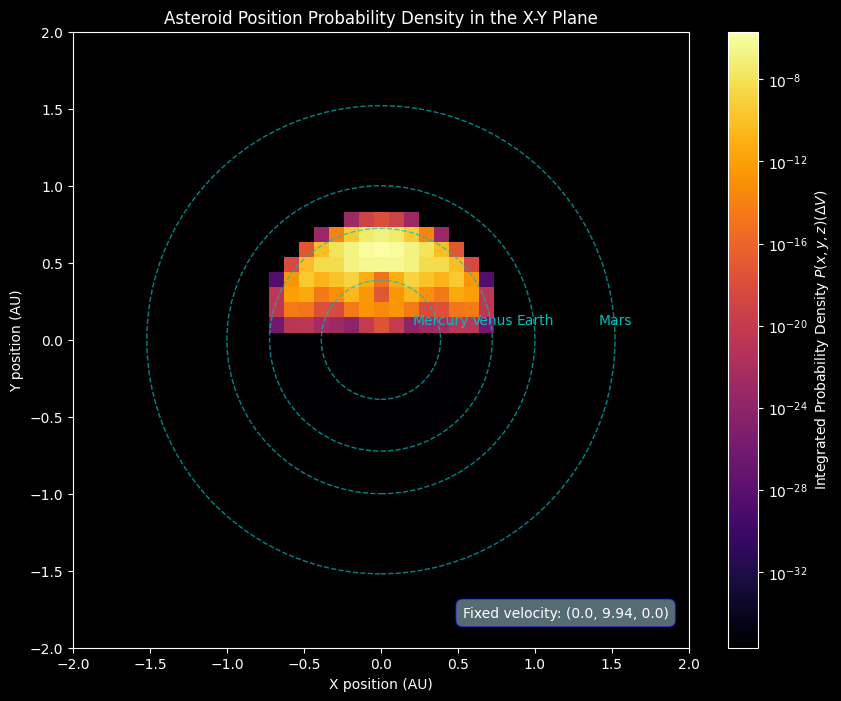

In [ ]:
with open("data_results/method 6/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T, 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest', 
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

In [91]:
integral_grid[15]

array([(0.00000000e+00, -2.00000000e+00, -0.5),
       (0.00000000e+00, -1.90000000e+00, -0.5),
       (0.00000000e+00, -1.80000000e+00, -0.5),
       (0.00000000e+00, -1.70000000e+00, -0.5),
       (0.00000000e+00, -1.60000000e+00, -0.5),
       (0.00000000e+00, -1.50000000e+00, -0.5),
       (0.00000000e+00, -1.40000000e+00, -0.5),
       (0.00000000e+00, -1.30000000e+00, -0.5),
       (0.00000000e+00, -1.20000000e+00, -0.5),
       (0.00000000e+00, -1.10000000e+00, -0.5),
       (0.00000000e+00, -1.00000000e+00, -0.5),
       (0.00000000e+00, -9.00000000e-01, -0.5),
       (0.00000000e+00, -8.00000000e-01, -0.5),
       (1.08189240e-34, -7.00000000e-01, -0.5),
       (1.16729022e-24, -6.00000000e-01, -0.5),
       (1.03480925e-22, -5.00000000e-01, -0.5),
       (1.56209280e-21, -4.00000000e-01, -0.5),
       (8.54159573e-21, -3.00000000e-01, -0.5),
       (1.03709425e-20, -2.00000000e-01, -0.5),
       (7.13735058e-22, -1.00000000e-01, -0.5),
       (1.42266355e-16,  1.77635684e-15,

In [92]:
integral_grid[25]

array([(0.00000000e+00, -2.00000000e+00, 0.5),
       (0.00000000e+00, -1.90000000e+00, 0.5),
       (0.00000000e+00, -1.80000000e+00, 0.5),
       (0.00000000e+00, -1.70000000e+00, 0.5),
       (0.00000000e+00, -1.60000000e+00, 0.5),
       (0.00000000e+00, -1.50000000e+00, 0.5),
       (0.00000000e+00, -1.40000000e+00, 0.5),
       (0.00000000e+00, -1.30000000e+00, 0.5),
       (0.00000000e+00, -1.20000000e+00, 0.5),
       (0.00000000e+00, -1.10000000e+00, 0.5),
       (0.00000000e+00, -1.00000000e+00, 0.5),
       (0.00000000e+00, -9.00000000e-01, 0.5),
       (0.00000000e+00, -8.00000000e-01, 0.5),
       (1.08189201e-34, -7.00000000e-01, 0.5),
       (1.16729022e-24, -6.00000000e-01, 0.5),
       (1.03480925e-22, -5.00000000e-01, 0.5),
       (1.56209280e-21, -4.00000000e-01, 0.5),
       (8.54159573e-21, -3.00000000e-01, 0.5),
       (1.03709425e-20, -2.00000000e-01, 0.5),
       (7.13735058e-22, -1.00000000e-01, 0.5),
       (1.42266355e-16,  1.77635684e-15, 0.5),
       (2.212

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_11480\1775542039.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


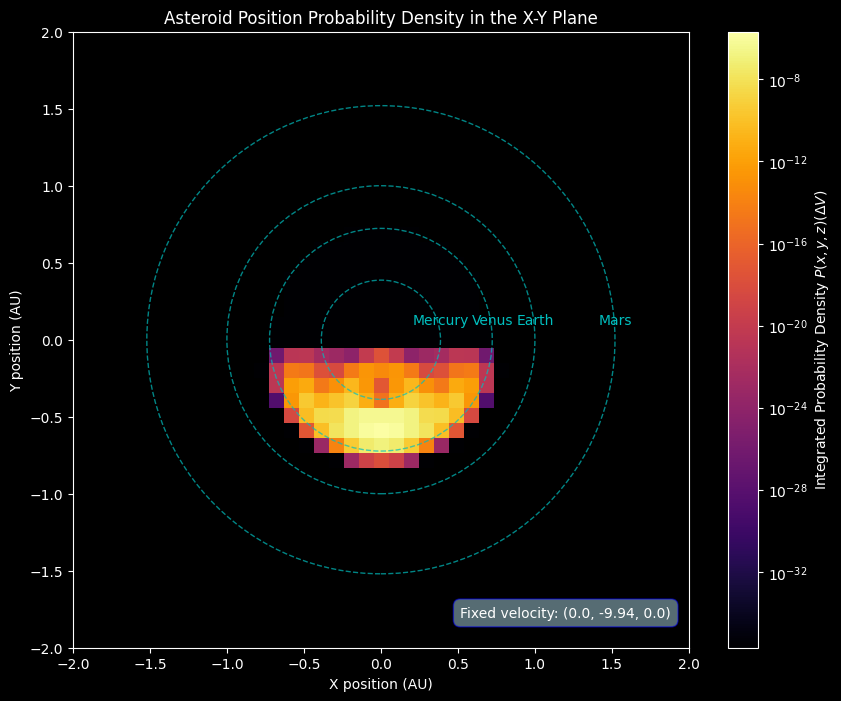

In [79]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -9.94

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'].T,
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-9.94_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\2075011767.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


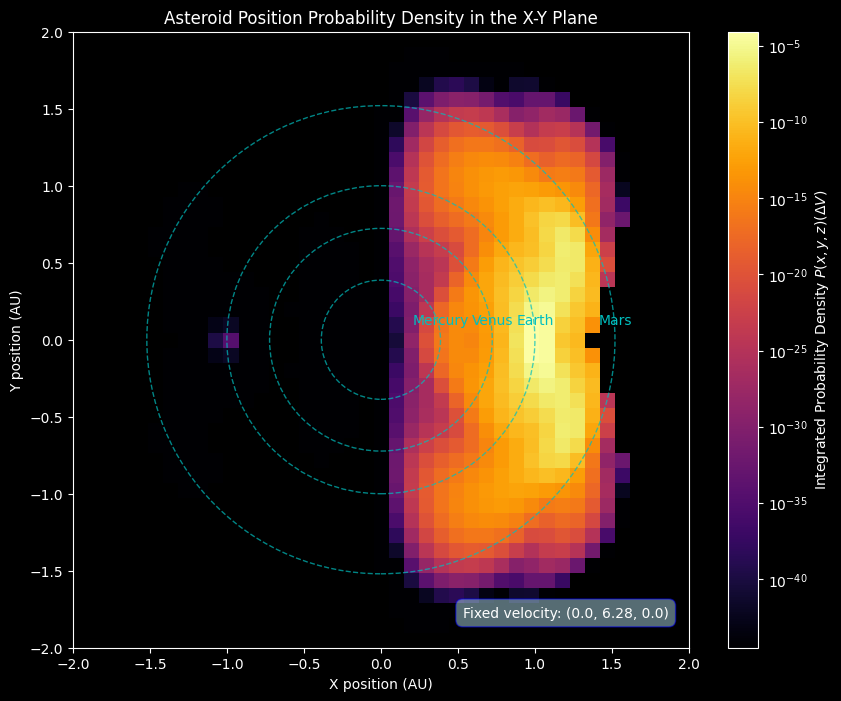

In [12]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = 6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box')
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3316823704.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')


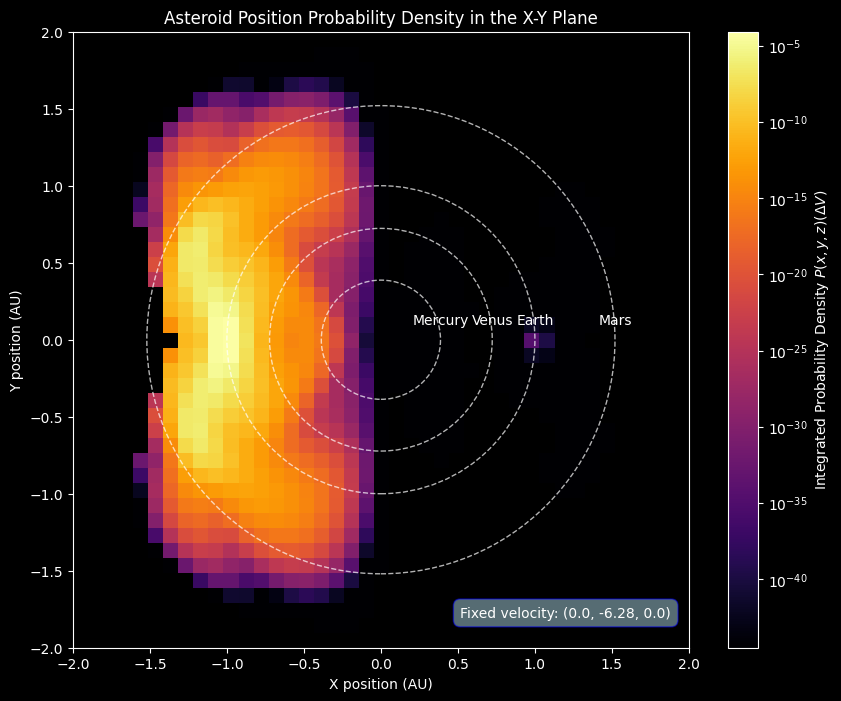

In [11]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2
vy = -6.28

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(x,y,z)(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Position Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(1.2, -1.8, f'Fixed velocity: ({vx}, {np.round(vy, 2)}, {vz})', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='white', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='white', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

#plt.savefig("figures/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=-6.28_vz=0.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\3118552977.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


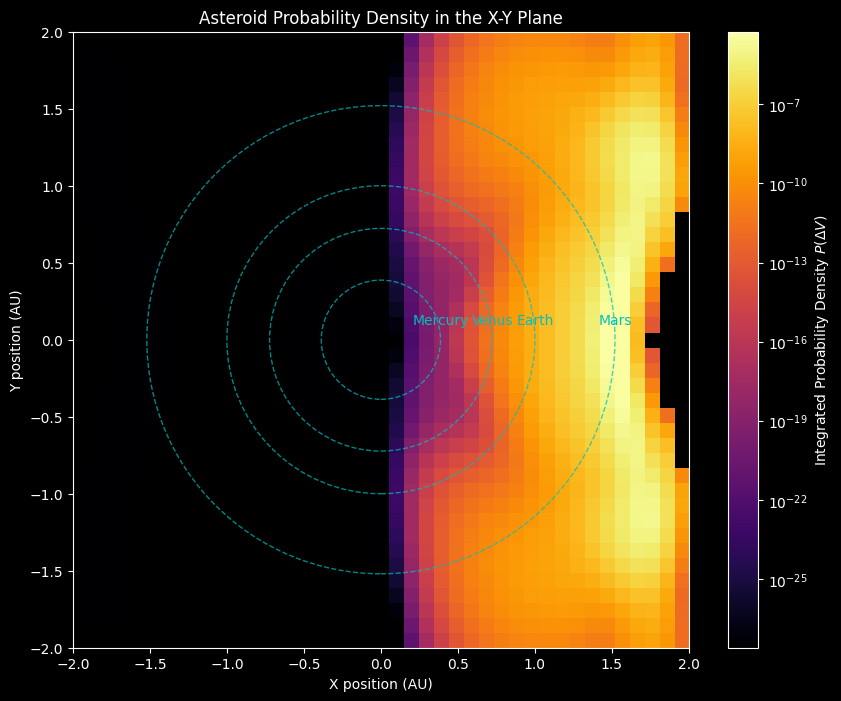

In [10]:
with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=4.44_vz=0.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\D'
<>:20: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_29176\289382936.py:20: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(\Delta V)$')


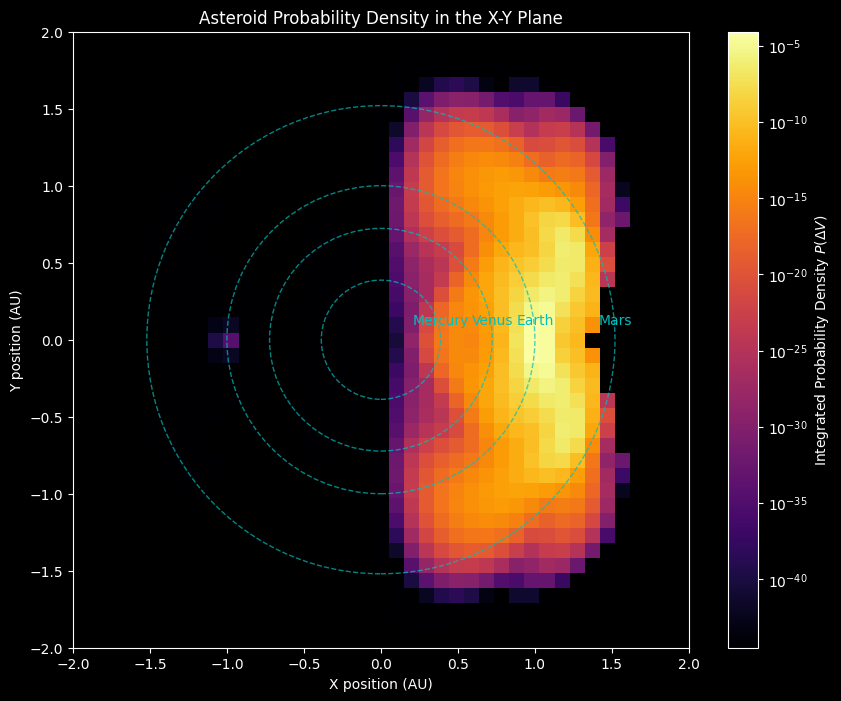

In [9]:

with open("data_results/method 6/PX_fixedv_xmin=-2_xmax=2_ymin=-2_ymax=2_vx=0.0_vy=6.28_vz=0.0_2.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

x_min, x_max = -2, 2
y_min, y_max = -2, 2

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    cmap='inferno',
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    interpolation='nearest',
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(\Delta V)$')

ax.set_xlabel('X position (AU)')
ax.set_ylabel('Y position (AU)')
ax.set_title('Asteroid Probability Density in the X-Y Plane')
ax.set_aspect('equal', adjustable='box') 

def plot_orbit(radius, label):
    circle = plt.Circle((0, 0), radius, color='c', fill=False, linestyle='--', alpha=0.7)
    ax.add_artist(circle)
    ax.text(radius, 0.1, label, color='c', ha='center')

plot_orbit(0.387, 'Mercury')
plot_orbit(0.723, 'Venus')
plot_orbit(1.0, 'Earth')
plot_orbit(1.52, 'Mars')

plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_9036\3813550909.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(vx,vy,vz)(\Delta V)$')


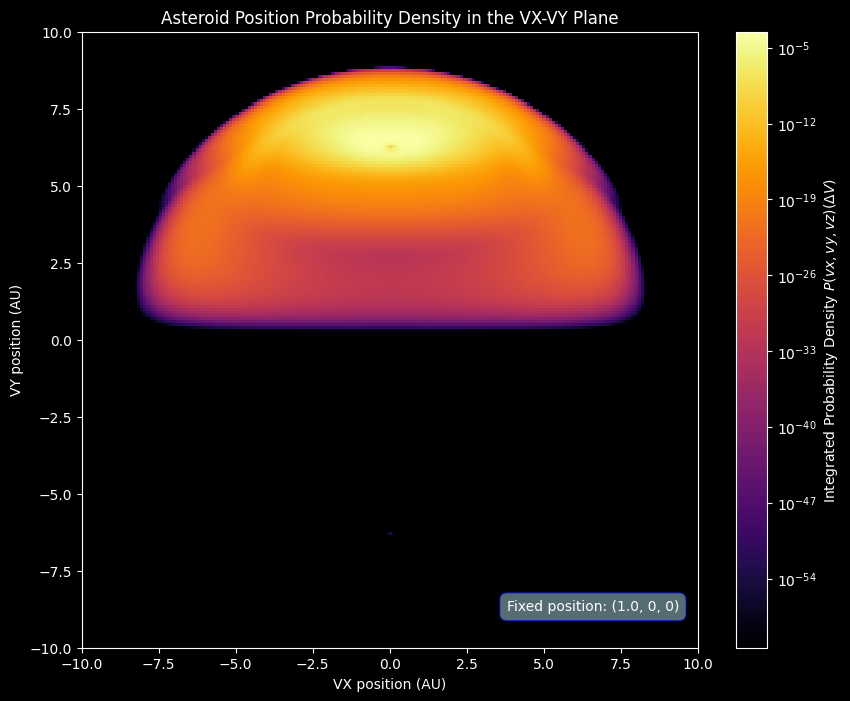

In [28]:
with open("data_results/method 6/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_x=1.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

vx_min, vx_max = -10, 10
vy_min, vy_max = -10, 10
x = 1.0

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[vx_min, vx_max, vy_min, vy_max],
    origin='lower',
    interpolation='nearest', 
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(vx,vy,vz)(\Delta V)$')

ax.set_xlabel('VX position (AU)')
ax.set_ylabel('VY position (AU)')
ax.set_title('Asteroid Position Probability Density in the VX-VY Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(6.6, -8.8, f'Fixed position: ({x}, 0, 0)', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))
plt.savefig("figures/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_x=1.0.png", dpi=300, bbox_inches='tight')

plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\D'
<>:22: SyntaxWarning: invalid escape sequence '\D'
C:\Users\aguju\AppData\Local\Temp\ipykernel_9036\794383500.py:22: SyntaxWarning: invalid escape sequence '\D'
  cbar.set_label('Integrated Probability Density $P(vx,vy,vz)(\Delta V)$')


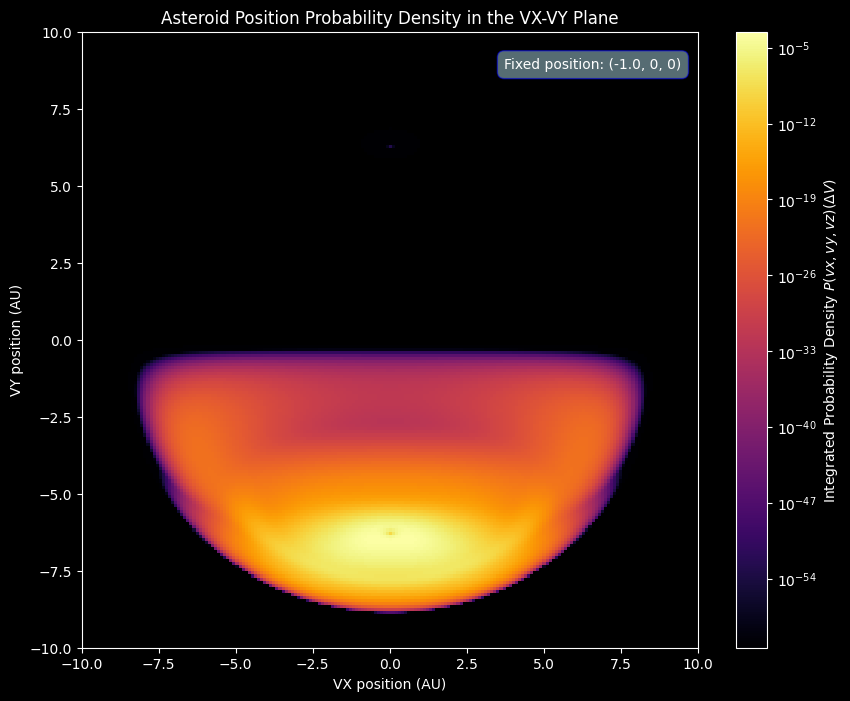

In [33]:
with open("data_results/method 6/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_x=-1.0.npy", "rb") as f:
    integral_grid = np.load(f, allow_pickle=False)

vx_min, vx_max = -10, 10
vy_min, vy_max = -10, 10
x = -1.0

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    integral_grid['value'], 
    #log_prob_map, # Uncomment this line to plot the log of the probability
    cmap='inferno',
    extent=[vx_min, vx_max, vy_min, vy_max],
    origin='lower',
    interpolation='nearest', 
    norm=LogNorm()
)

cbar = fig.colorbar(im)
cbar.set_label('Integrated Probability Density $P(vx,vy,vz)(\Delta V)$')

ax.set_xlabel('VX position (AU)')
ax.set_ylabel('VY position (AU)')
ax.set_title('Asteroid Position Probability Density in the VX-VY Plane')
ax.set_aspect('equal', adjustable='box') 
ax.text(6.6, 8.8, f'Fixed position: ({x}, 0, 0)', color='white', ha='center', bbox=dict(facecolor='lightblue', alpha=0.5, edgecolor='blue', boxstyle='round,pad=0.5'))
plt.savefig("figures/PX_fixedv_vxmin=-10_vxmax=10_vymin=-10_vymax=10_x=-1.0.png", dpi=300, bbox_inches='tight')

plt.show()